In [4]:
import json
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

CHOICES = ["A", "B", "C", "D"]


def load_data(path, key="forget_mcqa_prob"):
    with open(path, "r") as f:
        data = json.load(f)

    values = data[key]["value_by_index"]

    y_true = []
    y_pred = []
    probs = []

    for k in values:
        item = values[k]

        y_true.append(item["label"])
        y_pred.append(item["generated choice"])
        probs.append(item["prob"])

    probs = np.array(probs)

    return y_true, y_pred, probs


# -----------------------
# Accuracy + F1
# -----------------------

def compute_accuracy_f1(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return acc, f1


# -----------------------
# Brier score (multiclass)
# -----------------------

def compute_brier(y_true, probs):

    y_true_idx = np.array([CHOICES.index(y) for y in y_true])

    one_hot = np.zeros_like(probs)
    one_hot[np.arange(len(y_true_idx)), y_true_idx] = 1

    brier = np.mean(np.sum((probs - one_hot) ** 2, axis=1))

    return brier


# -----------------------
# ECE / MCE
# -----------------------

def compute_ece_mce(y_true, probs, n_bins=10):

    y_true_idx = np.array([CHOICES.index(y) for y in y_true])

    conf = np.max(probs, axis=1)
    pred = np.argmax(probs, axis=1)

    correct = (pred == y_true_idx).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0.0
    mce = 0.0

    for i in range(n_bins):

        mask = (conf >= bins[i]) & (conf < bins[i + 1])

        if np.sum(mask) == 0:
            continue

        acc_bin = np.mean(correct[mask])
        conf_bin = np.mean(conf[mask])

        gap = abs(acc_bin - conf_bin)

        ece += np.sum(mask) / len(conf) * gap
        mce = max(mce, gap)

    return ece, mce

# -----------------------
# Reliability Diagram
# -----------------------

import matplotlib.pyplot as plt
import numpy as np

CHOICES = ["A", "B", "C", "D"]


def plot_reliability_diagram(y_true, probs, n_bins=10):

    y_true_idx = np.array([CHOICES.index(y) for y in y_true])

    conf = np.max(probs, axis=1)
    pred = np.argmax(probs, axis=1)

    correct = (pred == y_true_idx).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)

    bin_acc = []
    bin_conf = []
    bin_count = []

    for i in range(n_bins):

        mask = (conf >= bins[i]) & (conf < bins[i + 1])

        if np.sum(mask) == 0:
            bin_acc.append(0)
            bin_conf.append(0)
            bin_count.append(0)
            continue

        bin_acc.append(np.mean(correct[mask]))
        bin_conf.append(np.mean(conf[mask]))
        bin_count.append(np.sum(mask))

    bin_acc = np.array(bin_acc)
    bin_conf = np.array(bin_conf)
    bin_count = np.array(bin_count)

    # ----- plot -----

    plt.figure()

    # bars = accuracy
    plt.bar(
        np.linspace(0.05, 0.95, n_bins),
        bin_acc,
        width=0.08,
        alpha=0.6,
        label="Accuracy",
    )

    # confidence line
    plt.plot(
        np.linspace(0.05, 0.95, n_bins),
        bin_conf,
        marker="o",
        label="Confidence",
    )

    # perfect calibration
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect")

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title("Reliability Diagram")

    plt.legend()
    plt.show()


# -----------------------
# MAIN
# -----------------------

def print_metrics_and_plot(path):
    
    ret_values = []
    
    for key in ["forget_mcqa_prob", "retain_mcqa_prob"]:
        print(f"--- {key} ---")
        y_true, y_pred, probs = load_data(path, key=key)

        acc, f1 = compute_accuracy_f1(y_true, y_pred)
        brier = compute_brier(y_true, probs)
        ece, mce = compute_ece_mce(y_true, probs, n_bins=10)

        print("Accuracy:", acc)
        print("F1:", f1)
        print("Brier:", brier)
        print("ECE:", ece)
        print("MCE:", mce)
        
        plot_reliability_diagram(y_true, probs, n_bins=10)
        
        ret_values.append({"key": key, "accuracy": acc, "f1": f1, "brier": brier, "ece": ece, "mce": mce})
        
    return ret_values

=== relu_Llama-3.1-8B-Instruct_full_retain99 ===
--- forget_mcqa_prob ---
Accuracy: 0.675
F1: 0.6227726574500767
Brier: 0.47190690689496384
ECE: 0.17350612208247185
MCE: 0.6952435374259949


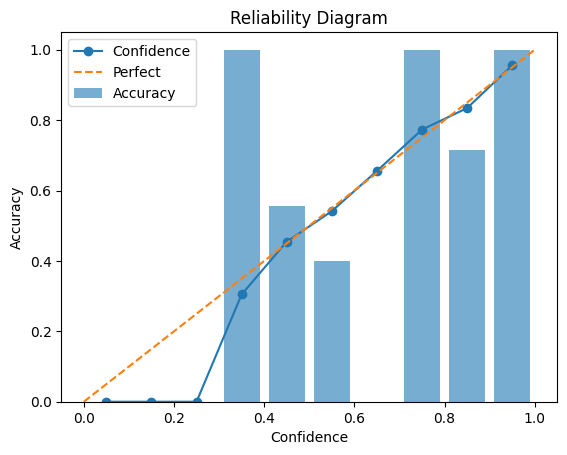

--- retain_mcqa_prob ---
Accuracy: 0.6832533468047487
F1: 0.6877278207469929
Brier: 0.4180406268644261
ECE: 0.04030515992391524
MCE: 0.10695095126117982


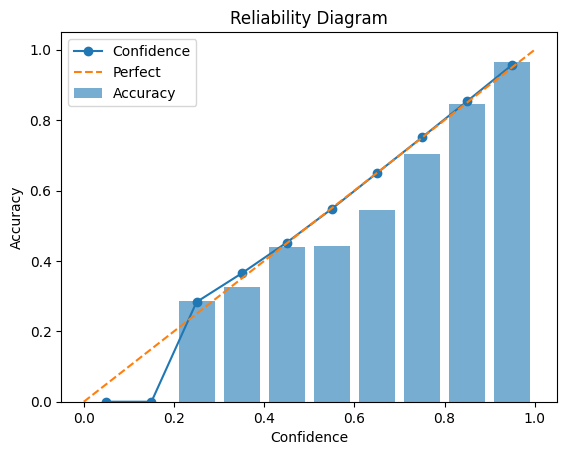

=== relu_Llama-3.1-8B-Instruct_full_retain95 ===
--- forget_mcqa_prob ---
Accuracy: 0.705
F1: 0.7043334877517722
Brier: 0.37568059192508735
ECE: 0.08183089375495911
MCE: 0.2110530138015747


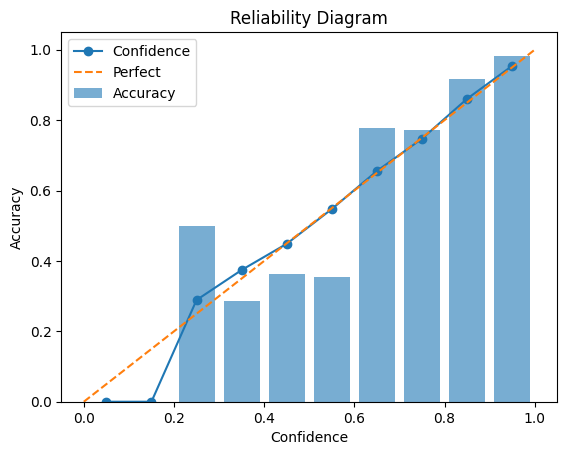

--- retain_mcqa_prob ---
Accuracy: 0.6870229007633588
F1: 0.6916720031995186
Brier: 0.41492479002666816
ECE: 0.039744394849745554
MCE: 0.2887454889714718


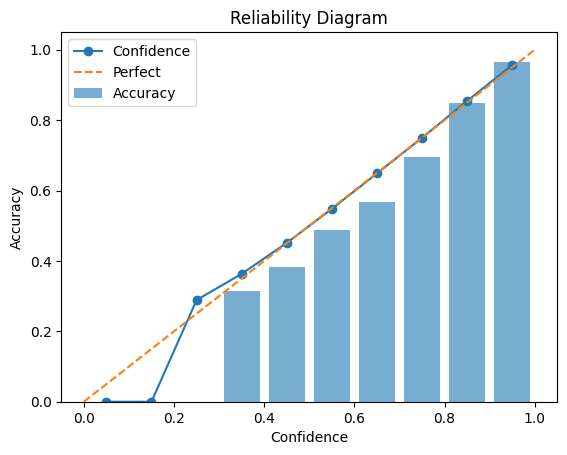

=== relu_Llama-3.1-8B-Instruct_full_retain90 ===
--- forget_mcqa_prob ---
Accuracy: 0.6716791979949874
F1: 0.6746596118952312
Brier: 0.4322328494942561
ECE: 0.0677879003803234
MCE: 0.2730233073234558


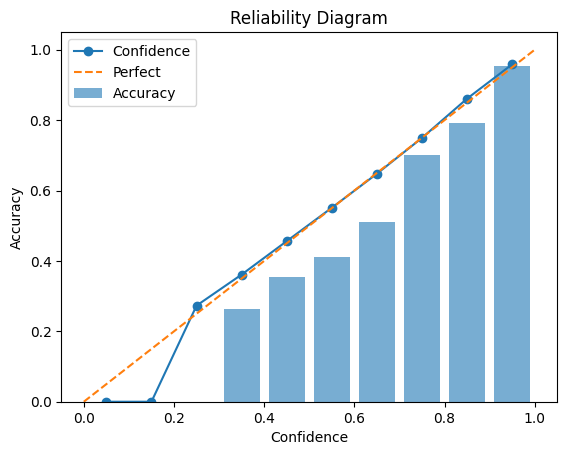

--- retain_mcqa_prob ---
Accuracy: 0.6944444444444444
F1: 0.6992634316956537
Brier: 0.4100207520477957
ECE: 0.03923106840915151
MCE: 0.06969826720343908


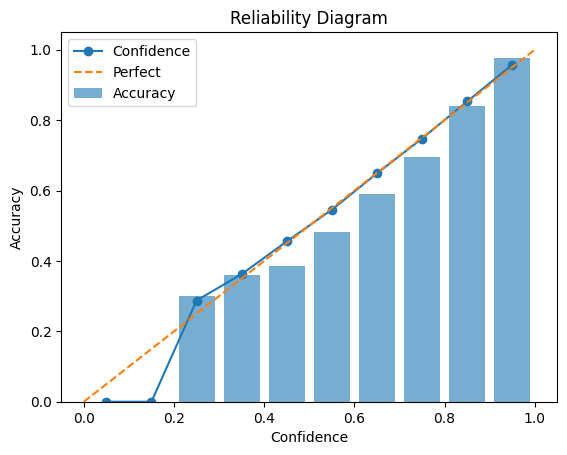

=== relu_Llama-3.1-8B-Instruct_pretrained_retain99 ===
--- forget_mcqa_prob ---
Accuracy: 0.275
F1: 0.23157690262953418
Brier: 1.0908492259918376
ECE: 0.43466744050383566
MCE: 0.768486758073171


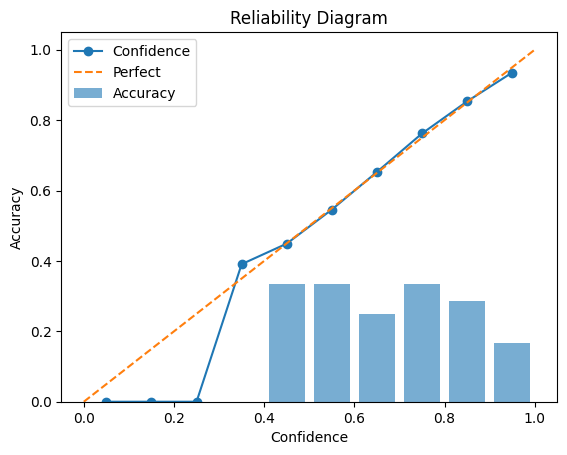

--- retain_mcqa_prob ---
Accuracy: 0.2631977772164688
F1: 0.1407672819904934
Brier: 1.1491766240873176
ECE: 0.5193650141663249
MCE: 0.6677646543093667


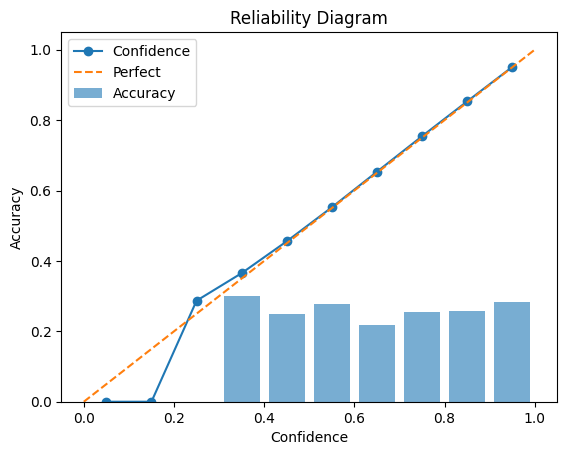

=== relu_Llama-3.1-8B-Instruct_pretrained_retain95 ===
--- forget_mcqa_prob ---
Accuracy: 0.25
F1: 0.11861876396128071
Brier: 1.1579450614611133
ECE: 0.5182619051635265
MCE: 0.7066642869086492


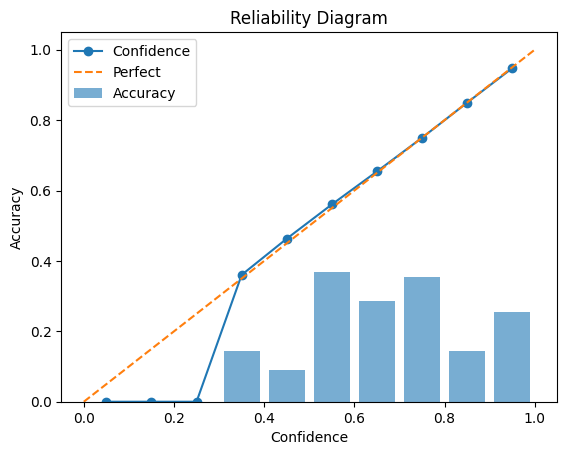

--- retain_mcqa_prob ---
Accuracy: 0.26033166622795473
F1: 0.14194567759314078
Brier: 1.1517394225319888
ECE: 0.522851302352947
MCE: 0.7046973705291748


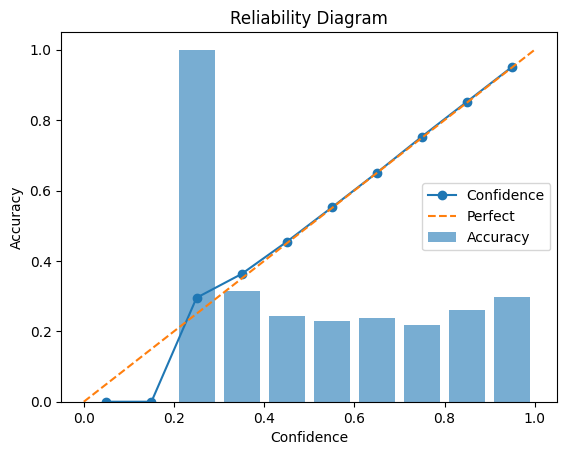

=== relu_Llama-3.1-8B-Instruct_pretrained_retain90 ===
--- forget_mcqa_prob ---
Accuracy: 0.2731829573934837
F1: 0.16608176624322846
Brier: 1.1075070929633692
ECE: 0.4965087265747232
MCE: 0.661733941871579


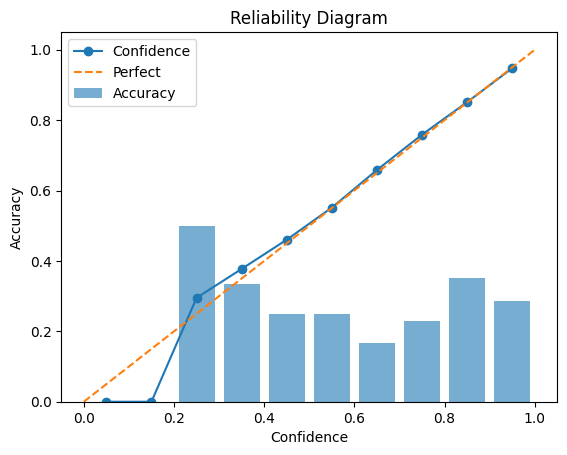

--- retain_mcqa_prob ---
Accuracy: 0.26555555555555554
F1: 0.14609762849888297
Brier: 1.143560509118443
ECE: 0.5162506141927508
MCE: 0.6652748292425406


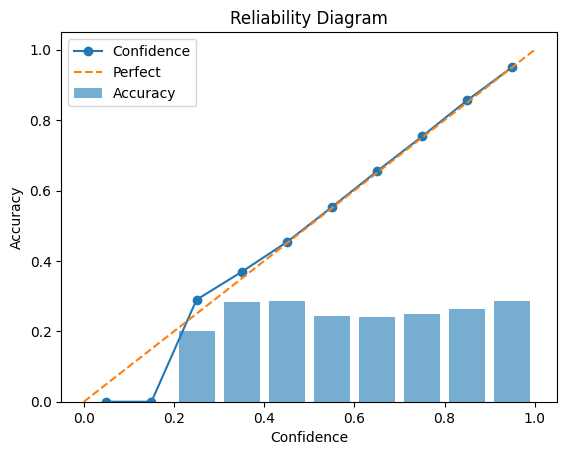

=== relu_Llama-3.1-8B-Instruct_retain90 ===
--- forget_mcqa_prob ---
Accuracy: 0.5864661654135338
F1: 0.5749254276178557
Brier: 0.5476023998057519
ECE: 0.08301350780597007
MCE: 0.298319548368454


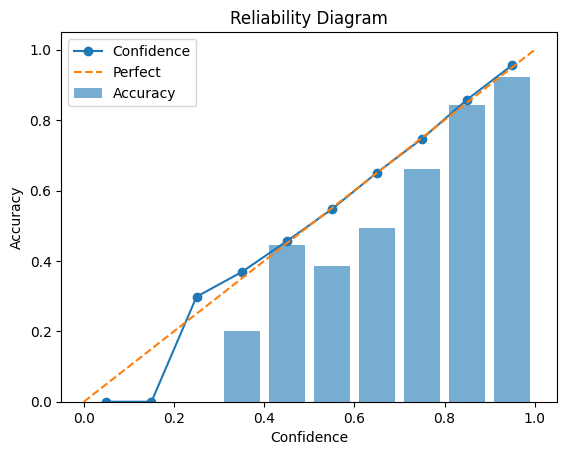

--- retain_mcqa_prob ---
Accuracy: 0.6386111111111111
F1: 0.6400443492631269
Brier: 0.47847177634139787
ECE: 0.03825575015611119
MCE: 0.08118397894784485


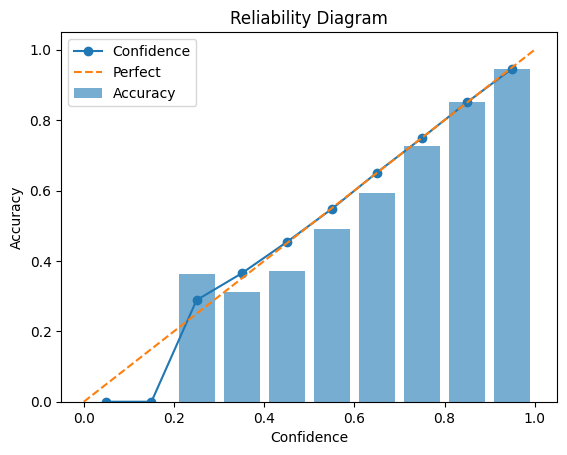

=== relu_Llama-3.1-8B-Instruct_retain95 ===
--- forget_mcqa_prob ---
Accuracy: 0.64
F1: 0.6358035576280447
Brier: 0.46979286571810575
ECE: 0.0668996988236904
MCE: 0.23151925103417764


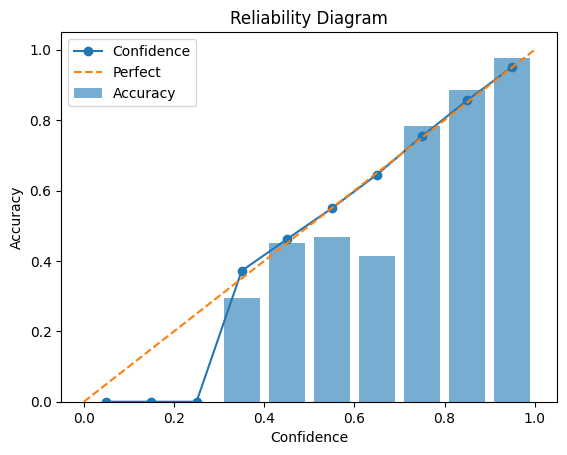

--- retain_mcqa_prob ---
Accuracy: 0.6928138983943143
F1: 0.6958633086640069
Brier: 0.41898097515963956
ECE: 0.03193633314432923
MCE: 0.13952575836862835


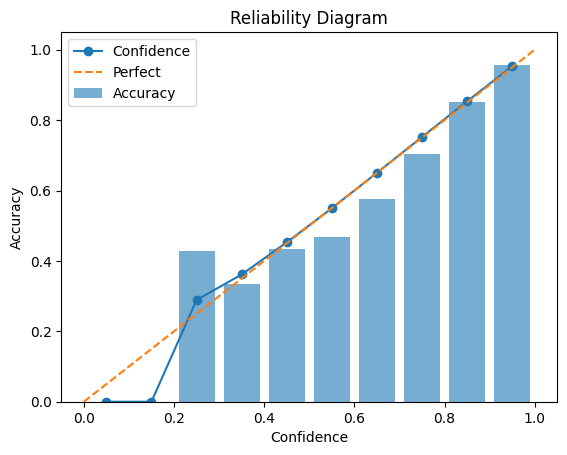

=== relu_Llama-3.1-8B-Instruct_retain99 ===
--- forget_mcqa_prob ---
Accuracy: 0.55
F1: 0.5247685185185185
Brier: 0.6435612535383071
ECE: 0.21184082925319675
MCE: 0.3569163580735525


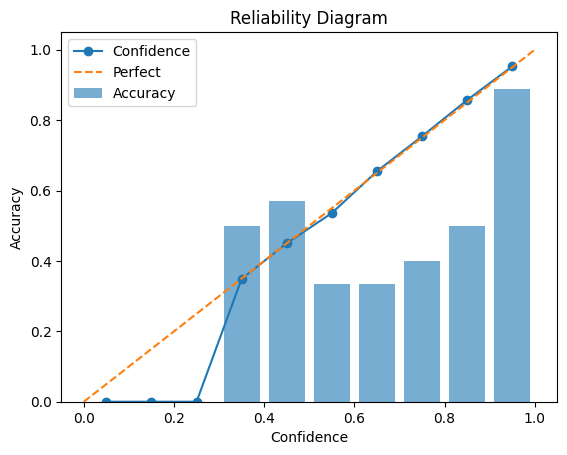

--- retain_mcqa_prob ---
Accuracy: 0.6627936347562515
F1: 0.6637298706834648
Brier: 0.4501174769149294
ECE: 0.04749719595692317
MCE: 0.09565991767354909


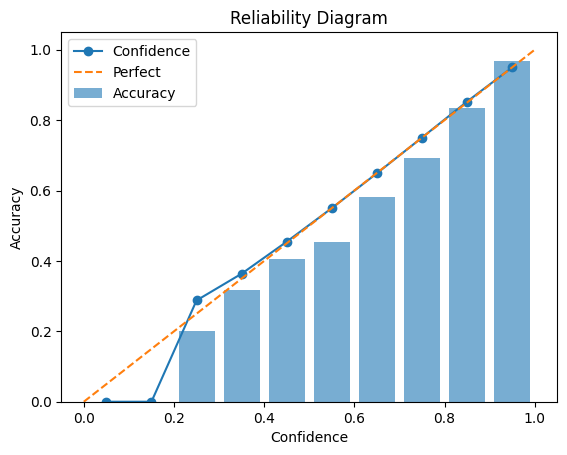

In [5]:
path_template = "/DATA3/divyaksh/Projects/inseq_testing/open-unlearning/saves/eval/{task_name}/RELU_EVAL.json"
tasks = [
    
    "relu_Llama-3.1-8B-Instruct_full_retain99",
    "relu_Llama-3.1-8B-Instruct_full_retain95",
    "relu_Llama-3.1-8B-Instruct_full_retain90",
    "relu_Llama-3.1-8B-Instruct_pretrained_retain99",
    "relu_Llama-3.1-8B-Instruct_pretrained_retain95",
    "relu_Llama-3.1-8B-Instruct_pretrained_retain90",
    "relu_Llama-3.1-8B-Instruct_retain90",
    "relu_Llama-3.1-8B-Instruct_retain95",
    "relu_Llama-3.1-8B-Instruct_retain99",
]

results = []

for task in tasks:
    try:
        print(f"=== {task} ===")
        metrics = print_metrics_and_plot(path_template.format(task_name=task))
        for m in metrics:
            results.append({"task": task, **m})
    except Exception as e:
        print(f"Error processing {task}: {e}")
        raise e
    
# store all the results in a JSON file
with open("/DATA3/divyaksh/Projects/inseq_testing/open-unlearning/saves/eval/calibration_results_only_8B.json", "w") as f:
    json.dump(results, f, indent=4)

=== relu_Llama-3.2-1B-Instruct_full_retain99 ===
--- forget_mcqa_prob ---
Accuracy: 0.275
F1: 0.23157690262953418
Brier: 1.0908492259918376
ECE: 0.43466744050383566
MCE: 0.768486758073171


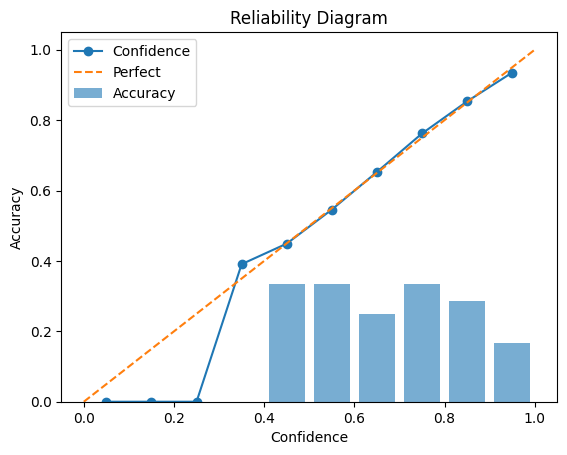

=== relu_Llama-3.2-1B-Instruct_full_retain95 ===
--- forget_mcqa_prob ---
Accuracy: 0.25
F1: 0.11861876396128071
Brier: 1.1579450614611133
ECE: 0.5182619051635265
MCE: 0.7066642869086492


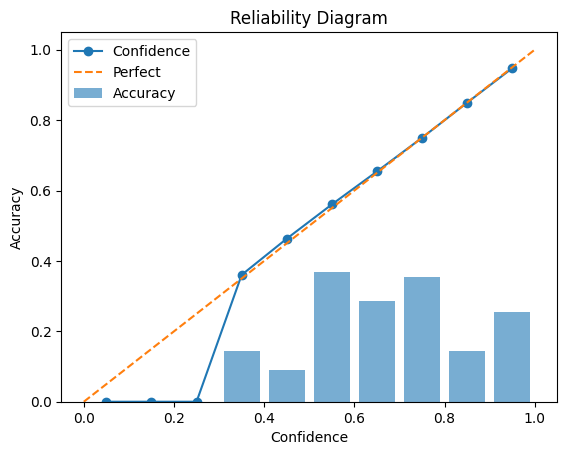

=== relu_Llama-3.2-1B-Instruct_full_retain90 ===
--- forget_mcqa_prob ---
Accuracy: 0.2731829573934837
F1: 0.16608176624322846
Brier: 1.1075070929633692
ECE: 0.4965087265747232
MCE: 0.661733941871579


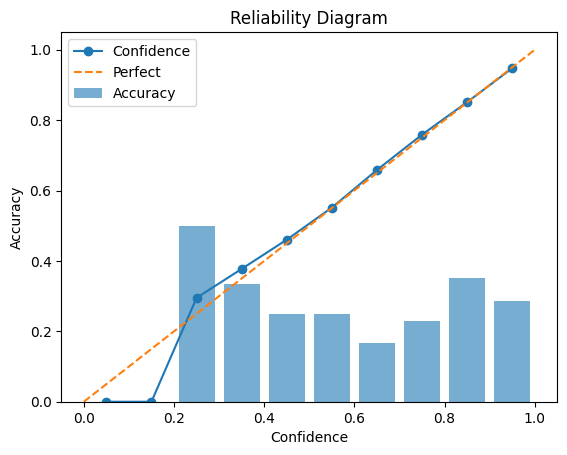

=== relu_Llama-3.2-1B-Instruct_pretrained_retain99 ===
--- forget_mcqa_prob ---
Accuracy: 0.275
F1: 0.23157690262953418
Brier: 1.0908492259918376
ECE: 0.43466744050383566
MCE: 0.768486758073171


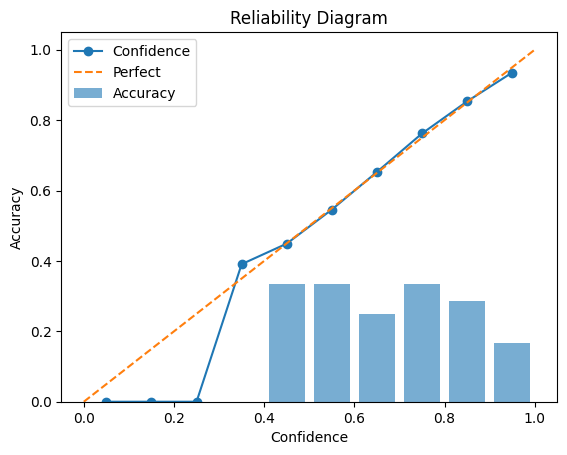

=== relu_Llama-3.2-1B-Instruct_pretrained_retain95 ===
--- forget_mcqa_prob ---
Accuracy: 0.25
F1: 0.11861876396128071
Brier: 1.1579450614611133
ECE: 0.5182619051635265
MCE: 0.7066642869086492


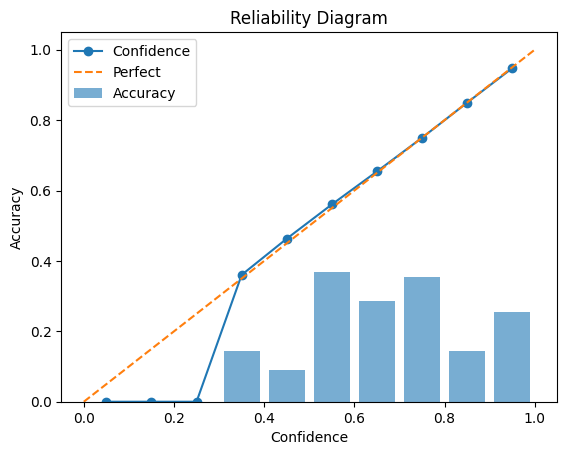

=== relu_Llama-3.2-1B-Instruct_pretrained_retain90 ===
--- forget_mcqa_prob ---
Accuracy: 0.2731829573934837
F1: 0.16608176624322846
Brier: 1.1075070929633692
ECE: 0.4965087265747232
MCE: 0.661733941871579


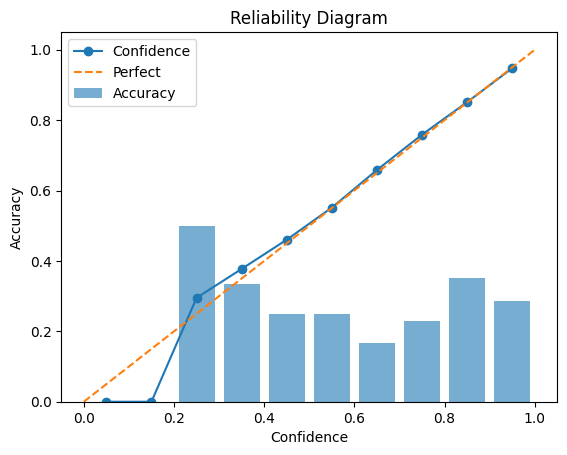

=== relu_Llama-3.2-1B-Instruct_retain90 ===
--- forget_mcqa_prob ---
Accuracy: 0.2781954887218045
F1: 0.17541562193832827
Brier: 1.021763207426524
ECE: 0.4074540823175196
MCE: 0.643499083518982


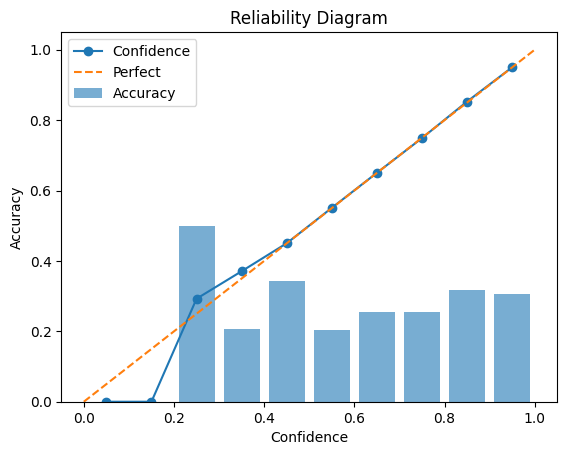

=== relu_Llama-3.2-1B-Instruct_retain95 ===
--- forget_mcqa_prob ---
Accuracy: 0.26
F1: 0.11970758452634785
Brier: 1.2488221977852936
ECE: 0.5791001981496811
MCE: 0.6887780094659457


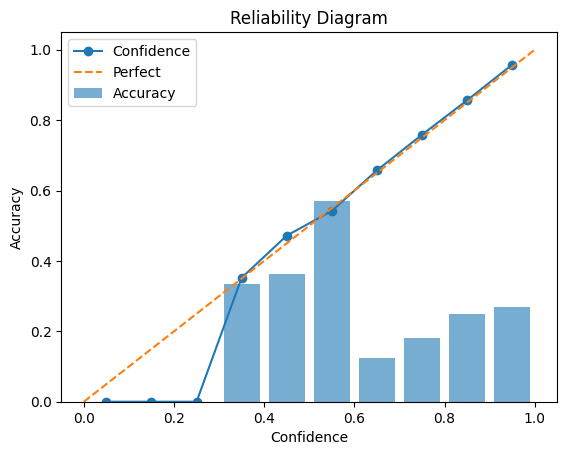

=== relu_Llama-3.2-1B-Instruct_retain99 ===
--- forget_mcqa_prob ---
Accuracy: 0.25
F1: 0.20279423808835573
Brier: 1.104998925785193
ECE: 0.44435307532548907
MCE: 0.7910809091159277


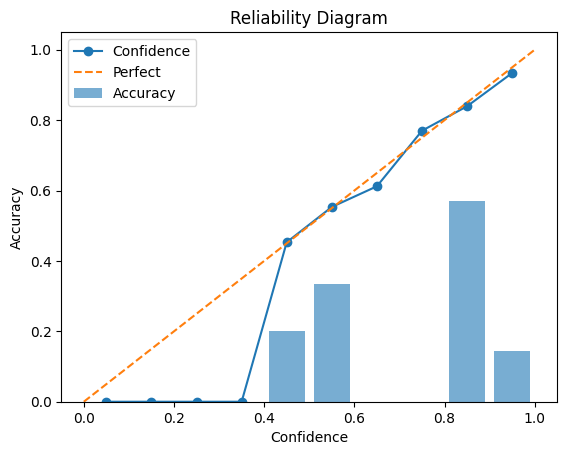

=== relu_Llama-3.2-3B-Instruct_full_retain99 ===
--- forget_mcqa_prob ---
Accuracy: 0.3
F1: 0.20101010101010103
Brier: 1.0299248950331066
ECE: 0.4118574865162373
MCE: 0.8666873648762703


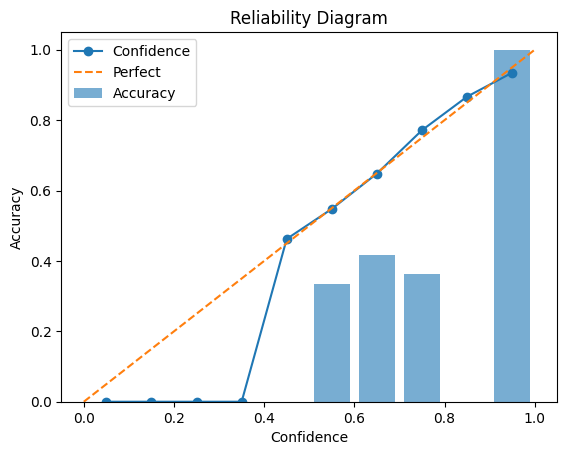

=== relu_Llama-3.2-3B-Instruct_full_retain95 ===
--- forget_mcqa_prob ---
Accuracy: 0.3
F1: 0.18755607315389922
Brier: 0.9616877023503275
ECE: 0.4107498781383037
MCE: 0.5679858982563019


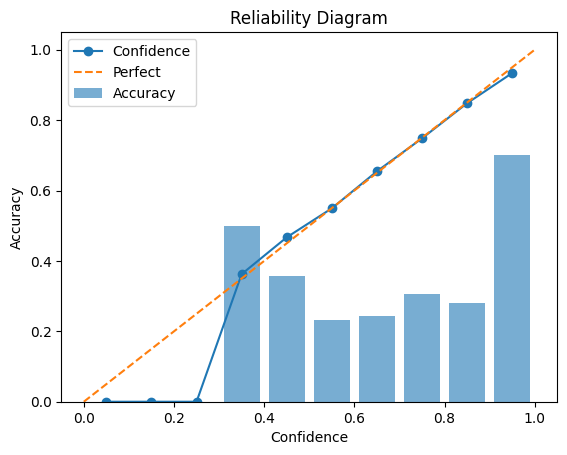

=== relu_Llama-3.2-3B-Instruct_full_retain90 ===
--- forget_mcqa_prob ---
Accuracy: 0.3182957393483709
F1: 0.23197707464948847
Brier: 0.9410616701488663
ECE: 0.38623152258700894
MCE: 0.49329923590024316


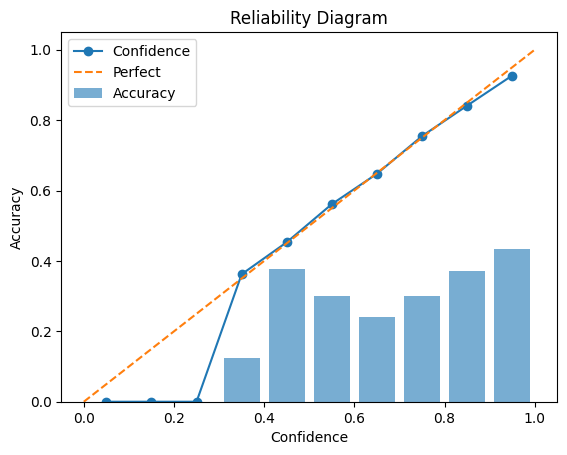

=== relu_Llama-3.2-3B-Instruct_pretrained_retain99 ===
--- forget_mcqa_prob ---
Accuracy: 0.275
F1: 0.23157690262953418
Brier: 1.0908492259918376
ECE: 0.43466744050383566
MCE: 0.768486758073171


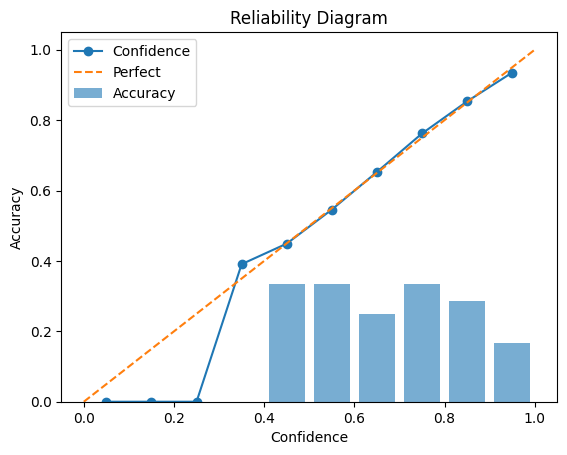

=== relu_Llama-3.2-3B-Instruct_pretrained_retain95 ===
--- forget_mcqa_prob ---
Accuracy: 0.25
F1: 0.11861876396128071
Brier: 1.1579450614611133
ECE: 0.5182619051635265
MCE: 0.7066642869086492


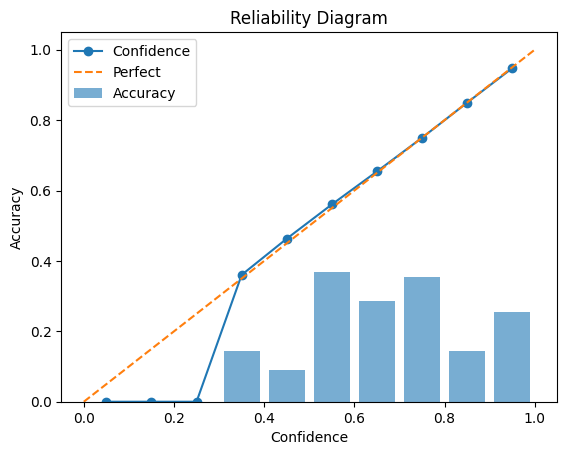

=== relu_Llama-3.2-3B-Instruct_pretrained_retain90 ===
--- forget_mcqa_prob ---
Accuracy: 0.2731829573934837
F1: 0.16608176624322846
Brier: 1.1075070929633692
ECE: 0.4965087265747232
MCE: 0.661733941871579


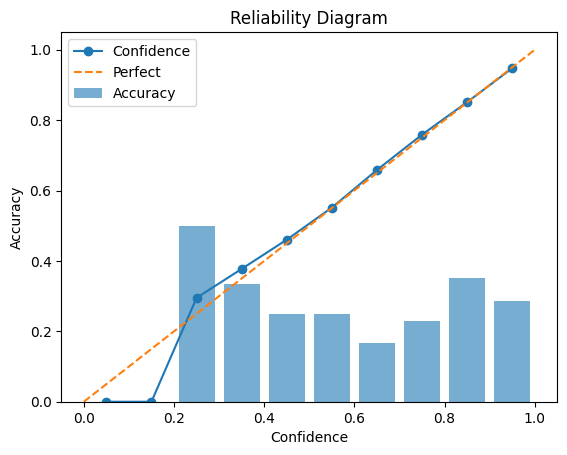

=== relu_Llama-3.2-3B-Instruct_retain90 ===
--- forget_mcqa_prob ---
Accuracy: 0.2706766917293233
F1: 0.1328336871446172
Brier: 1.0794110933653813
ECE: 0.49423128695117496
MCE: 0.7936176630583677


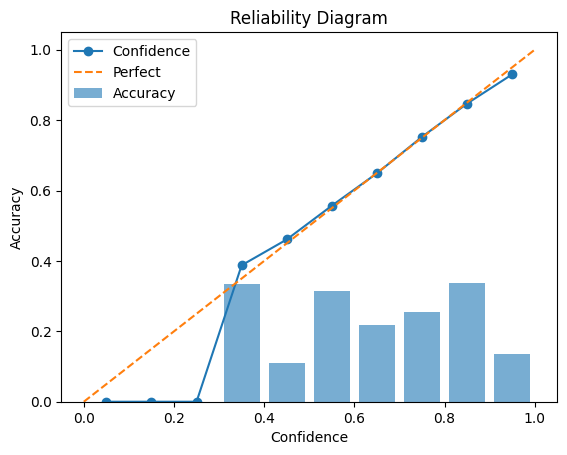

=== relu_Llama-3.2-3B-Instruct_retain95 ===
--- forget_mcqa_prob ---
Accuracy: 0.28
F1: 0.15515975212990818
Brier: 1.0251523778023794
ECE: 0.4511451873183251
MCE: 0.5490557849407196


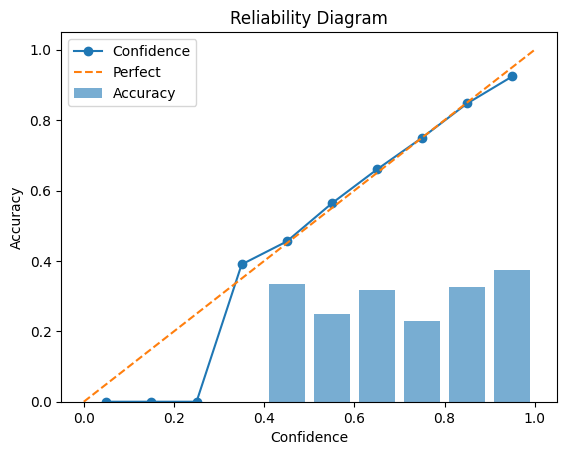

=== relu_Llama-3.2-3B-Instruct_retain99 ===
--- forget_mcqa_prob ---
Accuracy: 0.275
F1: 0.17269239711694956
Brier: 1.005197545836247
ECE: 0.43579326644539834
MCE: 0.9061899781227112


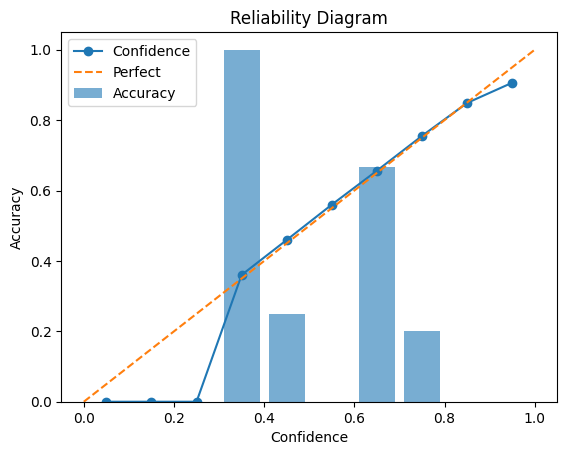

=== relu_Llama-3.1-8B-Instruct_full_retain99 ===
--- forget_mcqa_prob ---
Accuracy: 0.675
F1: 0.6227726574500767
Brier: 0.47190690689496384
ECE: 0.17350612208247185
MCE: 0.6952435374259949


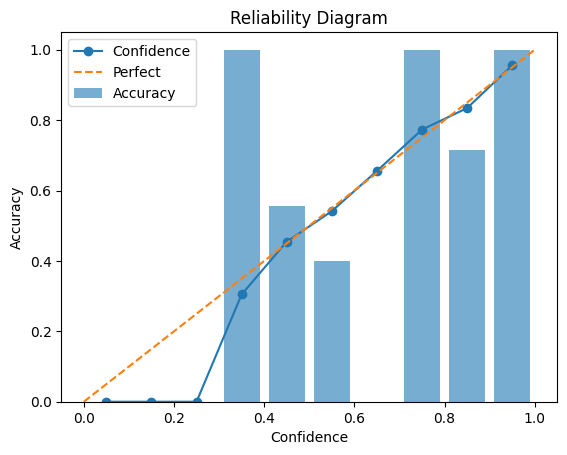

=== relu_Llama-3.1-8B-Instruct_full_retain95 ===
--- forget_mcqa_prob ---
Accuracy: 0.705
F1: 0.7043334877517722
Brier: 0.37568059192508735
ECE: 0.08183089375495911
MCE: 0.2110530138015747


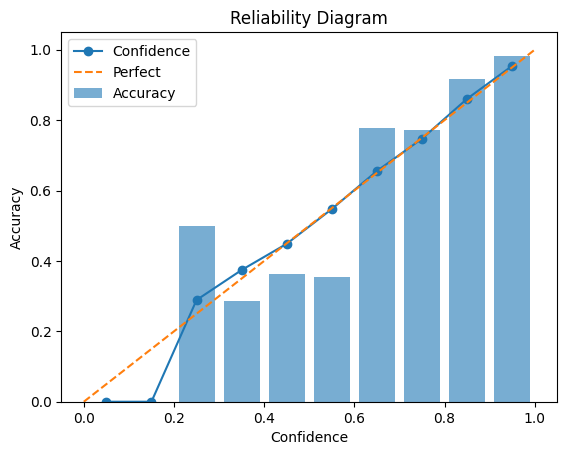

=== relu_Llama-3.1-8B-Instruct_full_retain90 ===
--- forget_mcqa_prob ---
Accuracy: 0.6716791979949874
F1: 0.6746596118952312
Brier: 0.4322328494942561
ECE: 0.0677879003803234
MCE: 0.2730233073234558


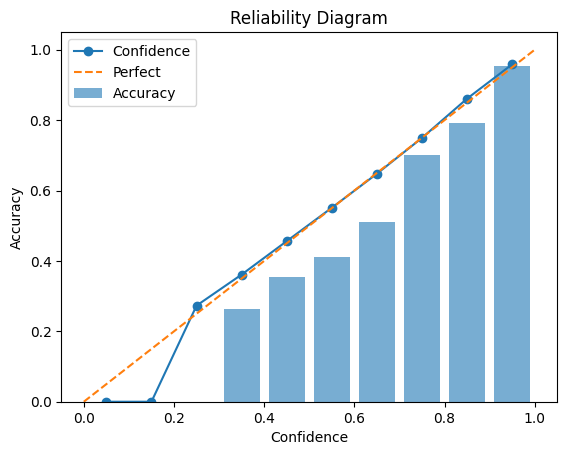

=== relu_Llama-3.1-8B-Instruct_pretrained_retain99 ===
--- forget_mcqa_prob ---
Accuracy: 0.275
F1: 0.23157690262953418
Brier: 1.0908492259918376
ECE: 0.43466744050383566
MCE: 0.768486758073171


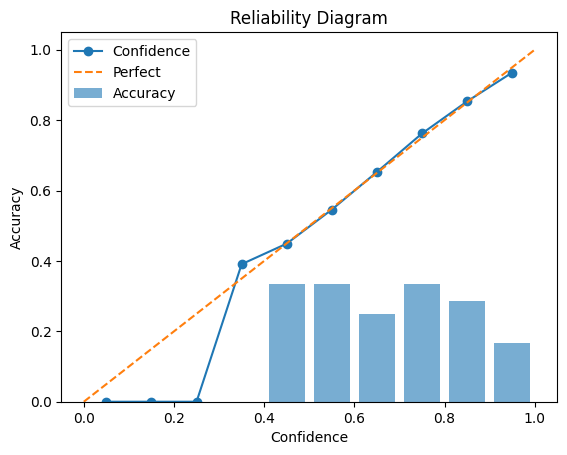

=== relu_Llama-3.1-8B-Instruct_pretrained_retain95 ===
--- forget_mcqa_prob ---
Accuracy: 0.25
F1: 0.11861876396128071
Brier: 1.1579450614611133
ECE: 0.5182619051635265
MCE: 0.7066642869086492


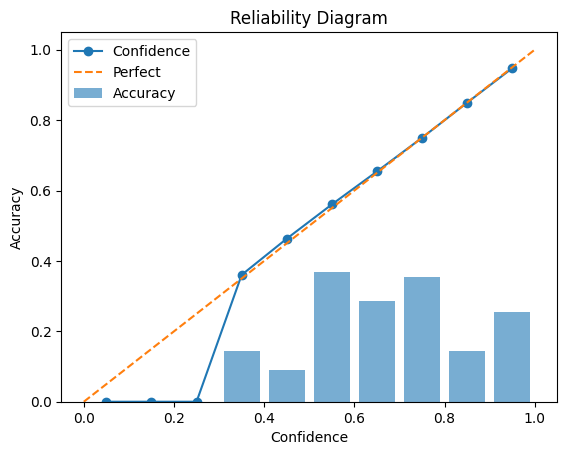

=== relu_Llama-3.1-8B-Instruct_pretrained_retain90 ===
--- forget_mcqa_prob ---
Accuracy: 0.2731829573934837
F1: 0.16608176624322846
Brier: 1.1075070929633692
ECE: 0.4965087265747232
MCE: 0.661733941871579


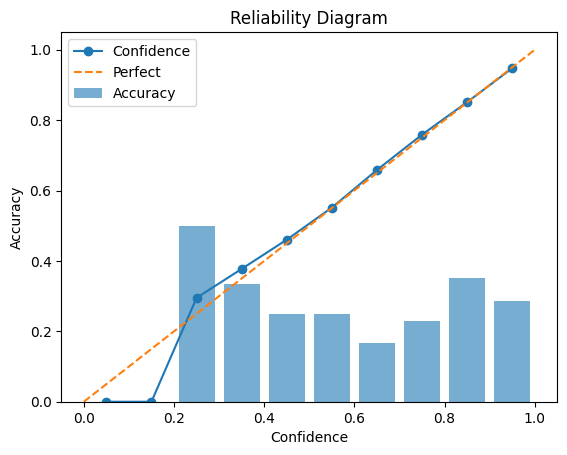

=== relu_Llama-3.1-8B-Instruct_retain90 ===
--- forget_mcqa_prob ---
Accuracy: 0.5864661654135338
F1: 0.5749254276178557
Brier: 0.5476023998057519
ECE: 0.08301350780597007
MCE: 0.298319548368454


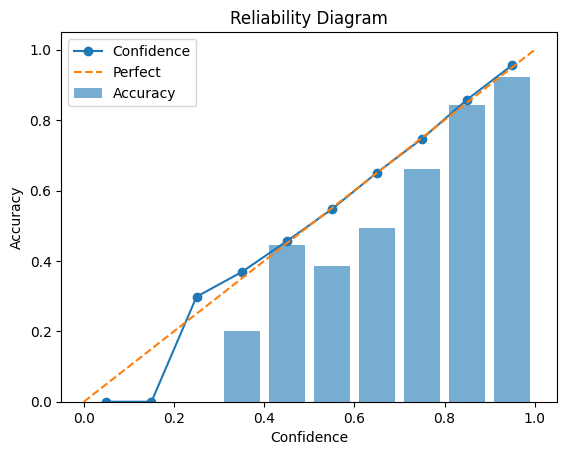

=== relu_Llama-3.1-8B-Instruct_retain95 ===
--- forget_mcqa_prob ---
Accuracy: 0.64
F1: 0.6358035576280447
Brier: 0.46979286571810575
ECE: 0.0668996988236904
MCE: 0.23151925103417764


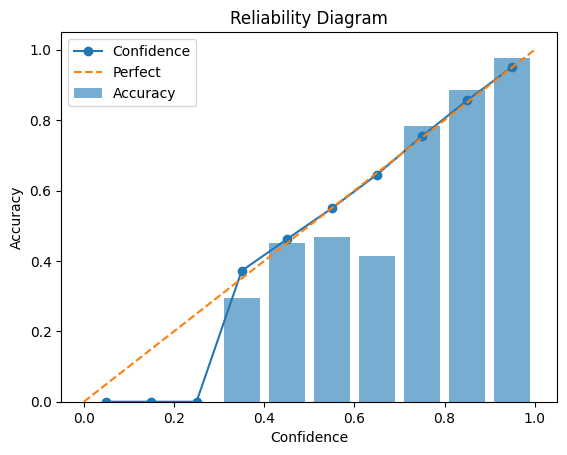

=== relu_Llama-3.1-8B-Instruct_retain99 ===
--- forget_mcqa_prob ---
Accuracy: 0.55
F1: 0.5247685185185185
Brier: 0.6435612535383071
ECE: 0.21184082925319675
MCE: 0.3569163580735525


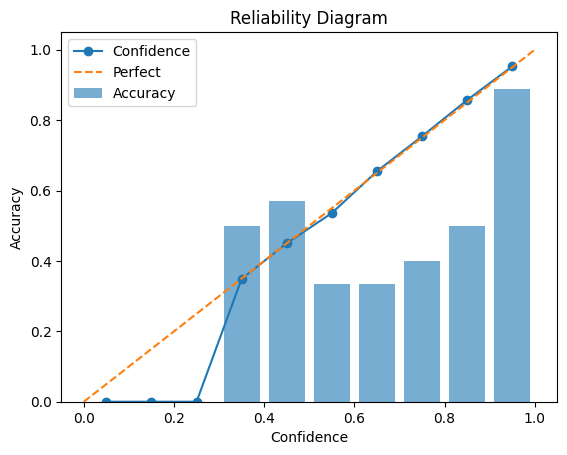

In [ ]:
path_template = "/DATA3/divyaksh/Projects/inseq_testing/open-unlearning/saves/eval/{task_name}/RELU_EVAL.json"
tasks = [
    "relu_Llama-3.2-1B-Instruct_full_retain99",
    "relu_Llama-3.2-1B-Instruct_full_retain95",
    "relu_Llama-3.2-1B-Instruct_full_retain90",
    "relu_Llama-3.2-1B-Instruct_pretrained_retain99",
    "relu_Llama-3.2-1B-Instruct_pretrained_retain95",
    "relu_Llama-3.2-1B-Instruct_pretrained_retain90",
    "relu_Llama-3.2-1B-Instruct_retain90",
    "relu_Llama-3.2-1B-Instruct_retain95",
    "relu_Llama-3.2-1B-Instruct_retain99",
    
    "relu_Llama-3.2-3B-Instruct_full_retain99",
    "relu_Llama-3.2-3B-Instruct_full_retain95",
    "relu_Llama-3.2-3B-Instruct_full_retain90",
    "relu_Llama-3.2-3B-Instruct_pretrained_retain99",
    "relu_Llama-3.2-3B-Instruct_pretrained_retain95",
    "relu_Llama-3.2-3B-Instruct_pretrained_retain90",
    "relu_Llama-3.2-3B-Instruct_retain90",
    "relu_Llama-3.2-3B-Instruct_retain95",
    "relu_Llama-3.2-3B-Instruct_retain99",
    
    "relu_Llama-3.1-8B-Instruct_full_retain99",
    "relu_Llama-3.1-8B-Instruct_full_retain95",
    "relu_Llama-3.1-8B-Instruct_full_retain90",
    "relu_Llama-3.1-8B-Instruct_pretrained_retain99",
    "relu_Llama-3.1-8B-Instruct_pretrained_retain95",
    "relu_Llama-3.1-8B-Instruct_pretrained_retain90",
    "relu_Llama-3.1-8B-Instruct_retain90",
    "relu_Llama-3.1-8B-Instruct_retain95",
    "relu_Llama-3.1-8B-Instruct_retain99",
]

results = []

for task in tasks:
    print(f"=== {task} ===")
    metrics = print_metrics_and_plot(path_template.format(task_name=task))
    results.append({"task": task, **metrics})
    
# store all the results in a JSON file
with open("/DATA3/divyaksh/Projects/inseq_testing/open-unlearning/saves/eval/calibration_results.json", "w") as f:
    json.dump(results, f, indent=4)